In [1]:
from pathlib import Path
import sys

def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "paths.json").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing config/paths.json")

REPO_ROOT = find_repo_root()
UTILS_DIR = REPO_ROOT / "code" / "utils"
if str(UTILS_DIR) not in sys.path:
    sys.path.append(str(UTILS_DIR))

from project_paths import ensure_project_dirs, load_project_paths

PATHS = ensure_project_dirs(load_project_paths(REPO_ROOT))

import pandas as pd
import numpy as np

participants_df = pd.read_csv(PATHS["participants_file"], sep="\t")
combined_df = pd.read_csv(PATHS["other_study_data_dir"] / "psychometry_long.tsv", sep="\t")
output_dir = PATHS["pk_pd_figures_root"]


In [2]:
timepoints_long_num = list(range(1, 8))
timepoints_long = [-1, 60, 80, 100, 180, 240, 300]
timepoints_short_num = list(range(1, 5))
timepoints_short = [40, 120, 140, 160]
metabolites = ["DMT", "3-IAA", "DMT-NO", "Harmine", "Harmol", "5-HT"]


Done


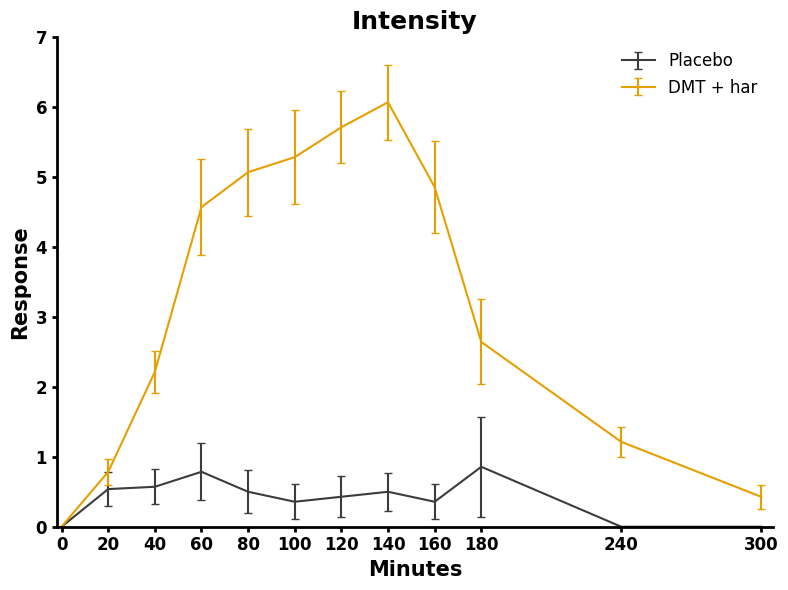

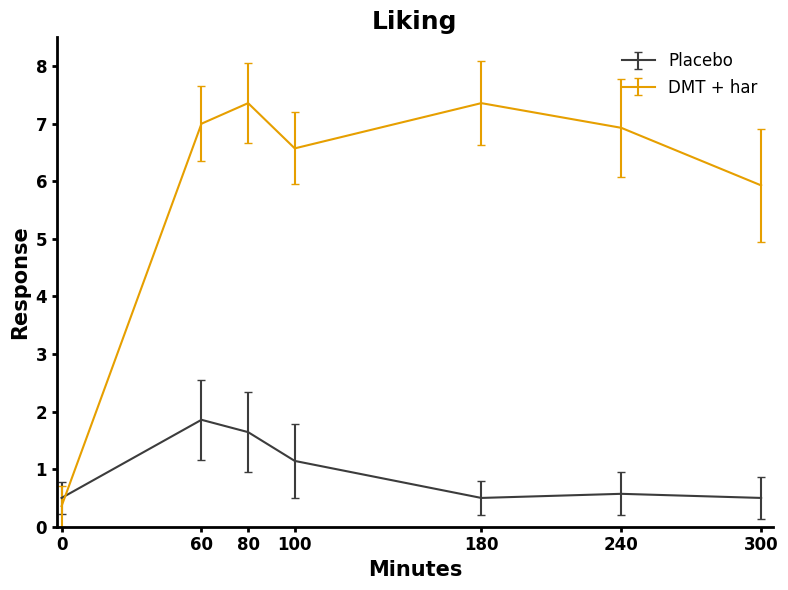

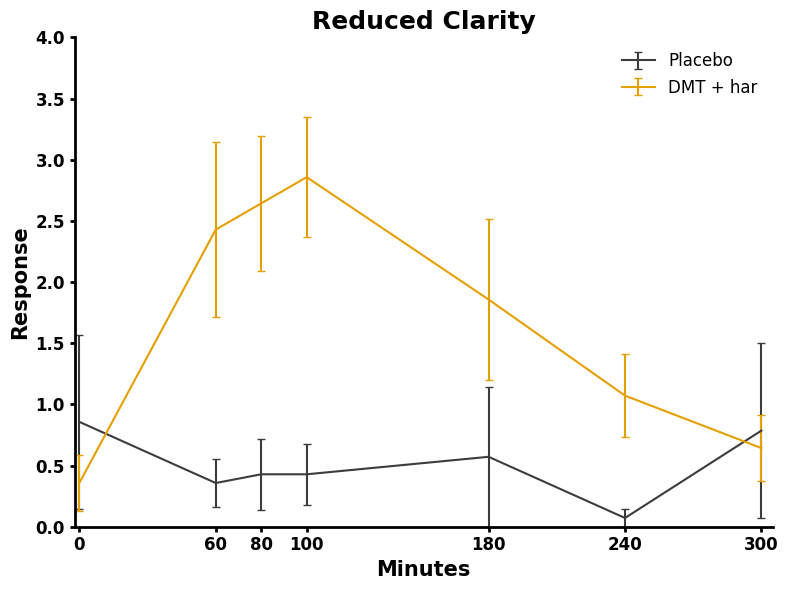

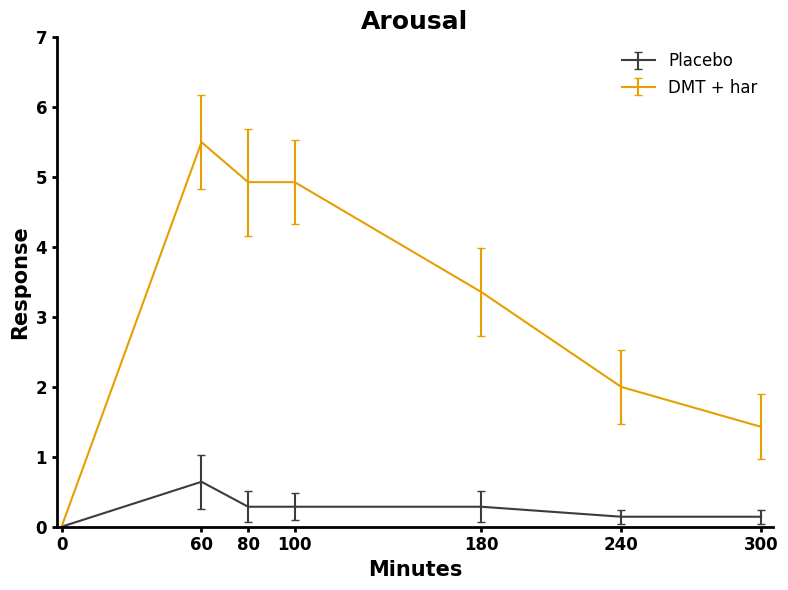

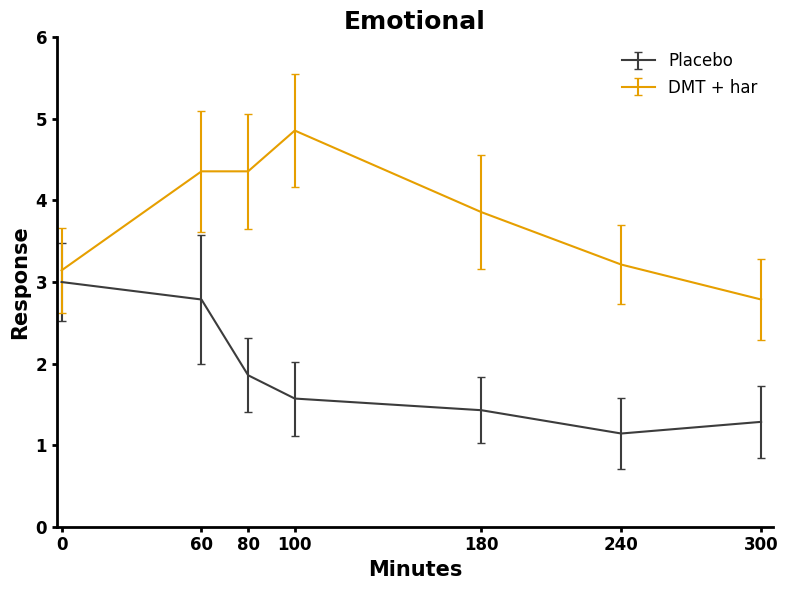

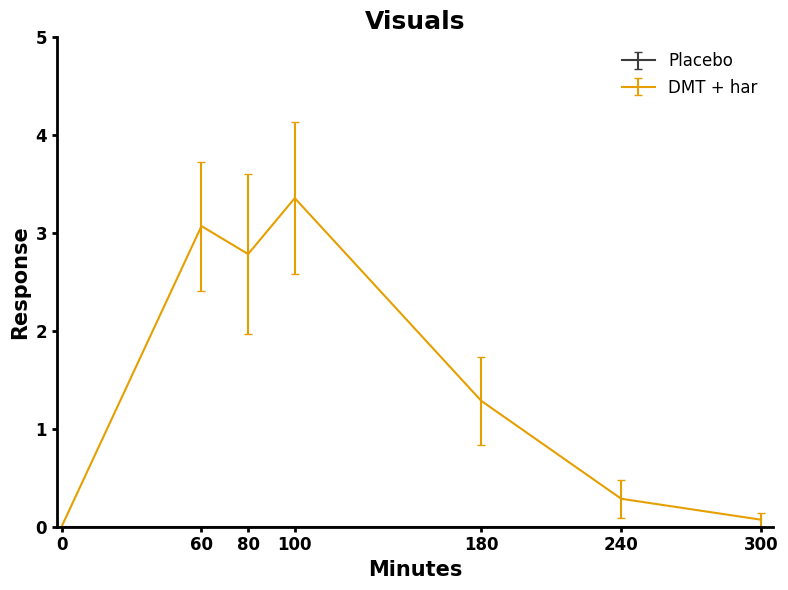

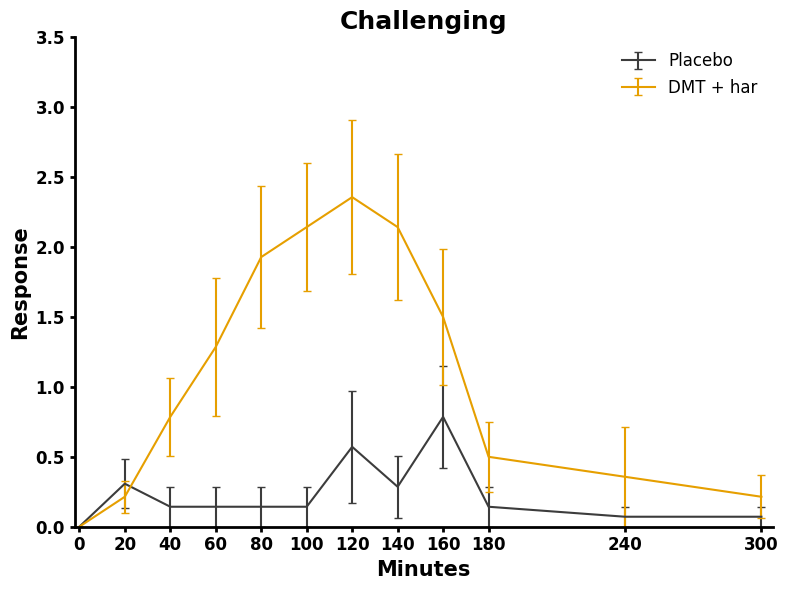

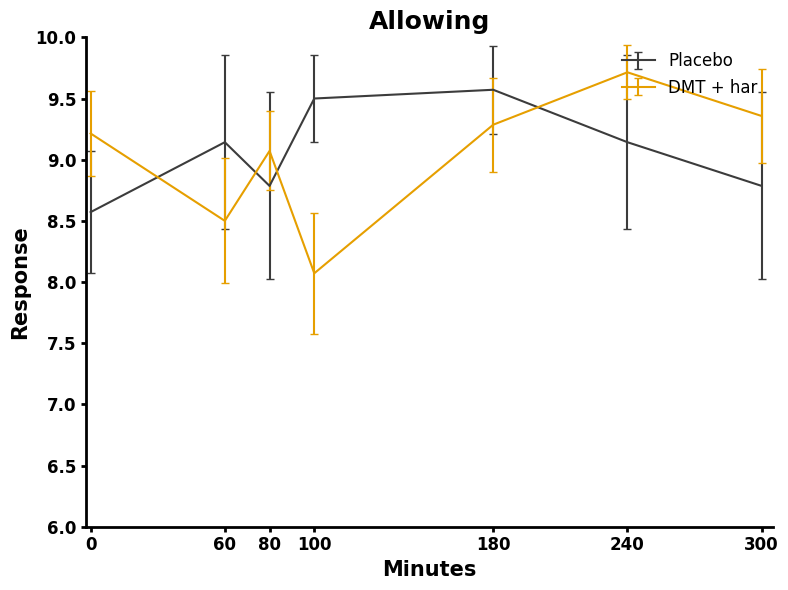

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem

# PIVOT
columns_to_fix = ['participant_id', 'session', 'Timepoint', 'drug_allocation']
df = combined_df.pivot(index=columns_to_fix, columns='Measure', values='Value').reset_index()
df['drug_allocation'] = df['drug_allocation'].replace('Verum', 'DMT + har')
df['Timepoint'] = df['Timepoint'].replace(-1, 0)

# Define colors and conditions
colors = {'Placebo': '#3C3C3C', 'DMT + har': '#E69F00'}
conditions = ['Placebo', 'DMT + har']

# Specify y-axis limits
y_lims = {
    'Intensity': [0, 7], 'Challenging': [0, 3.5], 'Emotional': [0, 6], 'Visuals': [0, 5],
    'Allowing': [6, 10], 'Liking': [0, 8.5], 'Reduced Clarity': [0, 4], 'Arousal': [0, 7]
}

# Plotting function
def plot_time_series(df, conditions, colors, response, save_name):
    fig, ax = plt.subplots(figsize=(8, 6))

    for idx, condition in enumerate(conditions):
        # Filter data for the specific condition
        condition_data = df[df['drug_allocation'] == condition]
        # Drop any rows with NaN values
        condition_data = condition_data.dropna(subset=[response])

        # Calculate mean and SEM for each timepoint
        mean_response = condition_data.groupby('Timepoint')[response].mean()
        sem_response = condition_data.groupby('Timepoint')[response].apply(sem)

        # Plot the time-series with error bars
        ax.errorbar(
            mean_response.index, mean_response, yerr=sem_response,
            label=condition, color=colors[condition], capsize=3
        )

    # Customize the plot
    ax.set_title(response, weight='bold', size=18)
    ax.set_xlabel('Minutes', weight='bold', size=15)
    ax.set_ylabel('Response', weight='bold', size=15)
    ax.set_ylim(y_lims[response])
    ax.grid(False)
    ax.set_xticks(sorted(condition_data["Timepoint"].unique()))
    ax.set_xlim(-2, 305)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.tick_params(axis='both', labelsize=12, width=2)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

    # Add legend
    ax.legend(fontsize=12, loc='upper right', frameon=False)

    # Adjust layout and save the plot
    fig.tight_layout()
    plt.savefig(os.path.join(output_dir, save_name), dpi=600)
    #plt.close(fig)

# Call the function for each response
RESPONSES = ['Intensity', 'Liking', 'Reduced Clarity', 'Arousal', 'Emotional', 'Visuals', 'Challenging', 'Allowing']
SAVE_NAMES = [
    'PD_Intensity_TimeSeries_lineplot.png', 'PD_Liking_TimeSeries_lineplot.png',
    'PD_ReducedClarity_TimeSeries_lineplot.png', 'PD_Arousal_TimeSeries_lineplot.png',
    'PD_Emotional_TimeSeries_lineplot.png', 'PD_Visuals_TimeSeries_lineplot.png',
    'PD_Challenging_TimeSeries_lineplot.png', 'PD_Allowing_TimeSeries_lineplot.png'
]

# Define required parameters
measure = ["Intensity", "Challenging", "Allowing", "Reduced Clarity", "Visuals", "Emotional", "Liking", "Arousal"]
measure_short = ["Intensity", "Challenging"]

for response, save_name in zip(RESPONSES, SAVE_NAMES):
    plot_time_series(df, conditions, colors, response, save_name)

print("Done")

In [4]:
from scipy.integrate import trapezoid

auc_intensity_data = []

# Filter the DataFrame for 'DMT + har' drug allocation
df_dmt_har = df[df["drug_allocation"] == "DMT + har"]

for pid, group in df_dmt_har.groupby("participant_id"):
    sub_df = group[["Timepoint", "Intensity"]].dropna().sort_values("Timepoint")

    sub_df_300 = sub_df[sub_df["Timepoint"] <= 300]
    auc_0_300 = (
        trapezoid(y=sub_df_300["Intensity"], x=sub_df_300["Timepoint"])
        if sub_df_300.shape[0] > 1 else np.nan
    )

    sub_df_100_180 = sub_df[(sub_df["Timepoint"] >= 100) & (sub_df["Timepoint"] <= 180)]
    auc_100_180 = (
        trapezoid(y=sub_df_100_180["Intensity"], x=sub_df_100_180["Timepoint"])
        if sub_df_100_180.shape[0] > 1 else np.nan
    )

    mean_intensity_100_180 = (
        sub_df_100_180["Intensity"].mean()
        if sub_df_100_180.shape[0] > 0 else np.nan
    )

    mean_intensity = (
        sub_df_300["Intensity"].mean()
        if sub_df_300.shape[0] > 0 else np.nan
    )

    max_intensity = sub_df["Intensity"].max()

    auc_intensity_data.append({
        "participant_id": pid,
        "AUC_0_300": round(auc_0_300, 1) if not np.isnan(auc_0_300) else np.nan,
        "AUC_100_180": round(auc_100_180, 1) if not np.isnan(auc_100_180) else np.nan,
        "Mean_Intensity_100_180": round(mean_intensity_100_180, 2) if not np.isnan(mean_intensity_100_180) else np.nan,
        "Mean_Intensity_0_300": round(mean_intensity, 2) if not np.isnan(mean_intensity) else np.nan,
        "Max_Intensity": round(max_intensity, 2) if not np.isnan(max_intensity) else np.nan
    })

auc_intensity_df = pd.DataFrame(auc_intensity_data)
auc_intensity_file_out = PATHS["pk_pd_tables_root"] / "preprocessed_df_intensity_auc.csv"
auc_intensity_df.to_csv(auc_intensity_file_out, index=False)
print(f"AUC Intensity data saved to: {auc_intensity_file_out}")


AUC Intensity data saved to: /Users/Edge/Documents/03_Research/01_PhD_Projekt/09_Analysis/04_HDP/HDP_fdg_pet_public_repo/outputs/tables/pk_pd/preprocessed_df_intensity_auc.csv


In [5]:
cmrglc_patlak_kinfitr_file = PATHS["kinfitr_output_root"] / '02_Outcomes' / '03_model_outcomes' / 'Patlak_outcomes.tsv'

cmrglc_patlak_data = pd.read_csv(cmrglc_patlak_kinfitr_file, sep="\t")
cmrglc_for_AUC_correlation = cmrglc_patlak_data[(cmrglc_patlak_data['condition'] == 'Verum') & (cmrglc_patlak_data['Region'] == 'whole_brain')]

cmrglc_whole_brain = cmrglc_patlak_data[cmrglc_patlak_data['Region'] == 'whole_brain']
cmrglc_pivot = cmrglc_whole_brain.pivot(index='sub', columns='condition', values='CMRglc')
cmrglc_pivot['delta_CMRglc'] = cmrglc_pivot['Verum'] - cmrglc_pivot['Placebo']
cmrglc_for_AUC_correlation = cmrglc_for_AUC_correlation.merge(
    cmrglc_pivot['delta_CMRglc'],
    left_on='sub',
    right_index=True,
    how='left'
)


## Correlation Mean Intensity with CMRglc

Mean_Intensity_100_180 (Intensity) vs. CMRglc correlation: r = 0.3902, p = 0.1678


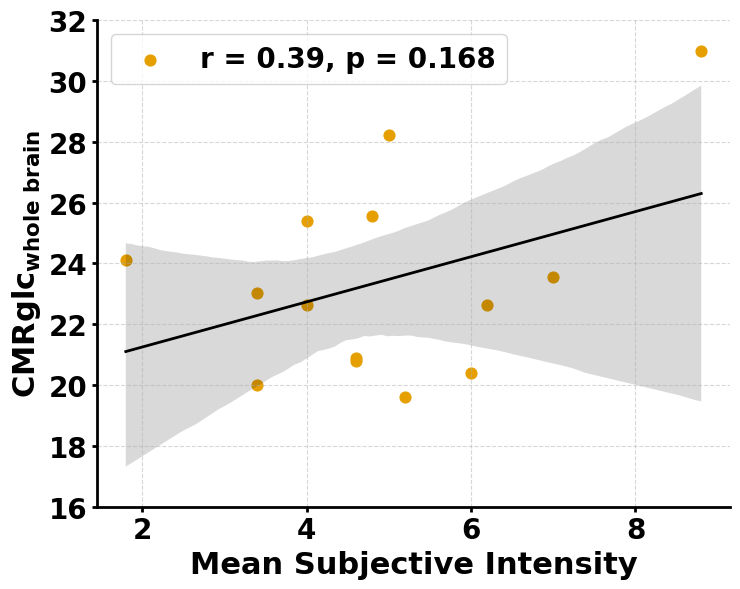

Mean_Intensity_100_180 (Intensity) vs. delta_CMRglc correlation: r = 0.3543, p = 0.2139


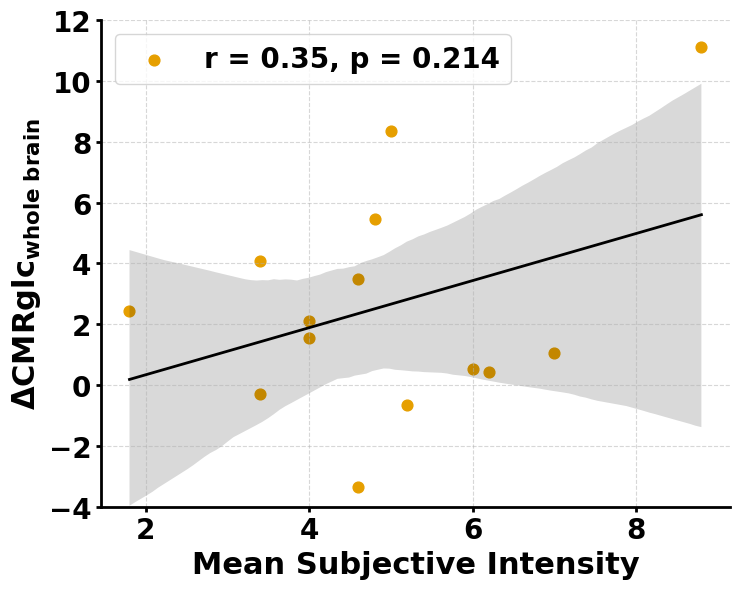

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

auc_intensity_df["sub"] = auc_intensity_df["participant_id"].str.replace("sub-", "").str.upper()

def plot_intensity_vs_cmrglc(
    cmrglc_df,
    intensity_df,
    y_column,
    y_label,
    y_limits,
    output_name=None,
):
    merged_df = pd.merge(cmrglc_df, intensity_df, on="sub")
    merged_df = merged_df.dropna(subset=["Mean_Intensity_100_180", y_column])

    x_vals = merged_df["Mean_Intensity_100_180"]
    y_vals = merged_df[y_column]

    corr, p_value = pearsonr(x_vals, y_vals)
    print(
        f"Mean_Intensity_100_180 (Intensity) vs. {y_column} correlation: "
        f"r = {corr:.4f}, p = {p_value:.4f}"
    )

    plt.figure(figsize=(7.5, 6))
    sns.regplot(
        x=x_vals,
        y=y_vals,
        scatter_kws={'alpha': 1, 's': 60},
        line_kws={'color': 'black', 'lw': 2},
        ci=95,
        color='#E69F00'
    )
    sns.despine()
    plt.gca().spines['left'].set_linewidth(2)
    plt.gca().spines['bottom'].set_linewidth(2)
    plt.xlabel("Mean Subjective Intensity", fontsize=22, weight='bold')
    plt.ylabel(y_label, fontsize=22)
    plt.legend([f'r = {corr:.2f}, p = {p_value:.3f}'], loc='upper left', prop={'weight': 'bold', 'size': 20})
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tick_params(axis='both', labelsize=20, width=2)
    if y_limits is not None:
        plt.ylim(y_limits)
    else:
        y_min, y_max = y_vals.min(), y_vals.max()
        padding = max((y_max - y_min) * 0.1, 0.5)
        plt.ylim(y_min - padding, y_max + padding)
    plt.setp(plt.gca().get_xticklabels(), fontweight='bold')
    plt.setp(plt.gca().get_yticklabels(), fontweight='bold')
    plt.tight_layout()
    if output_name is not None:
        plt.savefig(f"{output_dir}/{output_name}", dpi=600, bbox_inches='tight')
    plt.show()

plot_configs = [
    {
        "y_column": "CMRglc",
        "y_label": r"$\mathbf{CMRglc}_{\mathbf{whole\ brain}}$",
        "y_limits": (16, 32),
        "output_name": "correlations_CMRglc_with_mean_intensity.png",
    },
    {
        "y_column": "delta_CMRglc",
        "y_label": r"$\mathbf{\Delta CMRglc}_{\mathbf{whole\ brain}}$",
        "y_limits": (-4, 12),
        "output_name": "correlations_delta_CMRglc_with_mean_intensity.png",
    },
]

for plot_config in plot_configs:
    plot_intensity_vs_cmrglc(cmrglc_for_AUC_correlation, auc_intensity_df, **plot_config)
